# Set up library

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import os
import librosa
import json
import unicodedata
import pandas as pd






# Main

In [2]:
hop_length = 512
n_bins=84
bins_per_octave=12
fmin=librosa.note_to_hz('C3')

In [3]:
def get_CQT_of_a_audio(y, sr):
    
    C = librosa.cqt(
        y,
        sr=sr,
        hop_length=hop_length,
        fmin=fmin,
        n_bins=n_bins,
        bins_per_octave=bins_per_octave
    )

    return C

## Analyze pitch of audio

In [4]:
save_note_imge_path = "./Experiments/Data_Augmentation/Khèn 1/Pitches"

In [5]:
def get_notes_of_a_audio(notes, counts, file_name):

    note_midi = [librosa.note_to_midi(n) for n in notes]
    sorted_idx = np.argsort(note_midi)
    notes = notes[sorted_idx]
    counts = counts[sorted_idx]    

    plt.figure(figsize=(14,6))
    plt.bar(notes, counts, width=0.5)

    plt.xlabel("Notes")
    plt.ylabel("Counts")
    plt.title("Histogram of Notes")

    plt.xticks(rotation=45)
    plt.tight_layout()
    save_path = os.path.join(save_note_imge_path, file_name)
    plt.savefig(save_path , dpi=300)
    plt.close()

In [6]:
def extract_topk_pitch_to_json( cqt, sr, file_name, step, k=7, threshold = 0.1):

    n_frames = cqt.shape[1]
    max_energy = np.max(cqt)

    freqs = librosa.cqt_frequencies(
        n_bins=n_bins,
        fmin=fmin,
        bins_per_octave=bins_per_octave
    )


    times = librosa.frames_to_time(
        np.arange(n_frames),
        sr=sr
    )

    results = []

    notes = []

    for t in range(n_frames):
        frame = cqt[:, t]

        if frame.size == 0:
            continue

        top_k_idx = np.argsort(frame)[-k:][::-1]

        pitches = []
        for i in top_k_idx:
            current_energy = frame[i]
            if float(current_energy) < threshold * max_energy:
                continue

            pitches.append({
                "hz": float(freqs[i]),
                "note": librosa.hz_to_note(freqs[i]),
                "energy": float(frame[i])
            })

            notes.append(librosa.hz_to_note(freqs[i]))
        
        if len(pitches) > 0:
            results.append({
                "frame": int(t),
                "time": float(times[t]),
                "pitches": pitches
            })


    notes, counts = np.unique(notes, return_counts=True)
    note_count_dict = dict(zip(notes, counts))

    file_name = file_name + f" with pitch shift {step} step.png"

    get_notes_of_a_audio(notes, counts, file_name)

In [7]:
def extract_pitches_from_audios(audio_folder_path):
    if os.path.exists(audio_folder_path):
        for root, dirs, files in os.walk(audio_folder_path):
            for file in files:
                if file.endswith(".wav"):
                    audio_path = os.path.join(root, file)
                    cqt, sr = get_CQT_of_a_audio(audio_path)
                    extract_topk_pitch_to_json(cqt, sr, file.replace(".wav",""), threshold=0.2)
                    
    else:
        print("Cant find folder at", audio_folder_path)

## Data augmentation

### Pitch shift

In [8]:
def pitch_shift(y, sr, step):

    return librosa.effects.pitch_shift(y, sr=sr, n_steps= step)

### adding noise

In [9]:
def add_noise_snr(y, snr_db=10):
    noise = np.random.randn(len(y))

    rms_signal = np.sqrt(np.mean(y**2))
    rms_noise = np.sqrt(np.mean(noise**2))

    noise = noise * (rms_signal / (10**(snr_db / 20)) / (rms_noise + 1e-8))
    return y + noise

In [10]:
def augment_audio(y, sr, step):    

    y = pitch_shift(y, sr, step)

    if np.random.rand() < 0.5:
        y = add_noise_snr(y, snr_db=np.random.uniform(10, 20))

    return y

In [11]:
def analyze_spectrogram_by_CQT_of_audio_after_au(audio_path, save_path, file_name, step, get_pitches = False):

    step_folder_name = f"step = {step}"

    y, sr = librosa.load(audio_path, sr=None)

    y = augment_audio(y, sr, step)

    C = get_CQT_of_a_audio(y, sr)

    if get_pitches:
        extract_topk_pitch_to_json(C, sr, file_name, step)

    C_db = librosa.amplitude_to_db(np.abs(C))

    plt.figure(figsize=(12,6))

    librosa.display.specshow(
            C_db,
            sr=sr,
            hop_length=hop_length,
            x_axis='time',
            y_axis='cqt_note'
    )

    title = audio_path + f" after pitch shift {step} semitones"

    plt.title(title)

    plt.colorbar(format="%+2.0f dB")

    plt.tight_layout()

    file_name += ".png"

    save_path = os.path.join(save_path, step_folder_name, file_name)

    plt.savefig(save_path, dpi=300)

    plt.close()


In [12]:
def analyzing_spectrograms_after_au_from_a_qeej(audio_folder, save_path, ps_steps = []):


    if os.path.exists(audio_folder):
        for root, dirs, files in os.walk(audio_folder):
            for file in files:
                if file.endswith(".wav"):
                    audio_path = os.path.join(root, file)
                    for step in ps_steps:
                        analyze_spectrogram_by_CQT_of_audio_after_au(audio_path, save_path, file.replace(".wav", ""), step, True)
                    

                    
    else:
        print("Cant find folder at", audio_folder)

    

## Analyzing spectrogram of audio by CQT

In [13]:
results = {}
save_path = "./Experiments/Data_Augmentation"


In [ ]:

def preprocess_audio(audio):

    # normalize amplitude
    audio = audio / (np.max(np.abs(audio)) + 1e-8)

    return audio


def analyze_spectrogram_by_CQT_of_audio(audio_path, img_path, is_save = True):

    y, sr = librosa.load(audio_path, sr=None)

    C = get_CQT_of_a_audio(y, sr)
    
    n_frames = C.shape[1]

    frame_time = hop_length / sr

    times = np.arange(n_frames) * frame_time


    C_db = librosa.amplitude_to_db(np.abs(C))

    plt.figure(figsize=(12,6))

    librosa.display.specshow(
            C_db,
            sr=sr,
            hop_length=hop_length,
            x_axis='time',
            y_axis='cqt_note'
    )

    plt.title(audio_path)

    for t in times:
        plt.axvline(x=t, color='white', alpha = 0.5, linewidth=1)

    step = max(1, n_frames // 20)

    frame_ticks = np.arange(0, n_frames, step)
    frame_tick_times = frame_ticks * frame_time

    plt.xticks(frame_tick_times, frame_ticks)

    plt.xlabel("Frame index")

    plt.colorbar(format="%+2.0f dB")

    plt.tight_layout()

    if is_save:
        plt.savefig(img_path, dpi=300)
    else:
        plt.show()
    plt.close()

    

def analyzing_spectrograms_for_audios_in_folder(audio_folder):

    audio_folder_name = "audio"
    img_folder_name = "spectrograms_fixed"

    if os.path.exists(audio_folder):
        for root, dirs, files in os.walk(audio_folder):
            for file in files:
                if file.endswith(".wav"):
                    img_root = root.replace(audio_folder_name, img_folder_name)
                if os.path.exists(img_root):
                    img_file_name = file.replace(".wav", ".png")
                    img_path = os.path.join(img_root, img_file_name)
                    audio_path = os.path.join(root, file)
                    analyze_spectrogram_by_CQT_of_audio(audio_path, img_path)
                    
                    
                else:
                    print(img_root, "doesnt exists !")
                    
    else:
        print("Cant find folder at", audio_folder)

    

In [15]:

# def detect_multi_pitchs_of_audio(audio_path):

#     model_output, midi_data, note_events = predict(audio_path)

#     freqs = []

#     for note in note_events:
#         pitch = note[2]
#         freq = 440 * 2 ** ((pitch - 69)/12)
#         freqs.append(freq)

#     results[audio_path] = freqs


## Helper to create csv file

In [16]:
def create_label_template(audio_path, output_csv, hop_length=512):

    y, sr = librosa.load(audio_path, sr=None)

    duration = librosa.get_duration(y=y, sr=sr)

    frame_time = hop_length / sr

    total_frames = int(duration / frame_time)

    frames = np.arange(total_frames)

    start_times = frames * frame_time
    end_times = start_times + frame_time

    df = pd.DataFrame({
        "frame": frames,
        "start_time": start_times,
        "end_time": end_times,
        "label": "Default"
    })

    df.to_csv(output_csv, index=False)

def create_labels_for_audios_in_folder(audio_folder, audio_folder_name = "audio", csv_folder_name = "frame_labels"):


    if os.path.exists(audio_folder):
        for root, dirs, files in os.walk(audio_folder):
            for file in files:
                if file.endswith(".wav"):
                    csv_root = root.replace(audio_folder_name, csv_folder_name)
                if os.path.exists(csv_root):
                    csv_file_name = file.replace(".wav", ".csv")
                    csv_path = os.path.join(csv_root, csv_file_name)
                    audio_path = os.path.join(root, file)
                    create_label_template(audio_path, csv_path)
                    
                    
                else:
                    print(csv_root, "doesnt exists !")
                    
    else:
        print("Cant find folder at", audio_folder)


## Create Csv file 

In [ ]:
# audio_folder = "./Data/audio_extends"
# create_labels_for_audios_in_folder(audio_folder, audio_folder_name="audio_extends")

## assess all audio

In [18]:
#  # read data from drive
# audio_data_set_paths =  ["./Data/audio/Khèn 1/Đơn_ống",
#                          "./Data/audio/Khèn 2 (vừa)/Đơn ống",
#                          "./Data/audio/Khèn 3 (vừa)/Đơn ống",
#                          "./Data/audio/Khèn 4 (to)/Đơn ống",
#                          "./Data/audio/Khèn 5 (to)/Đơn ống",
#                          "./Real Data/Khèn 1/Đơn âm",
#                          "./Real Data/Khèn 2/Đơn âm",
#                          "./Real Data/Khèn 3/Đơn âm",
#                          "./Real Data/Khèn 4/Đơn âm"]

# index = 0
# for audio_data_set_path in audio_data_set_paths:
#     if os.path.exists(audio_data_set_path):
#       for root, dirs, files in os.walk(audio_data_set_path):
#         for file in files:
#           if file.endswith(".wav"):
#             audio_file_path = os.path.join(root, file)
#             file_name = file.replace(".wav","") + f"from qeej {index}"
#             analyze_spectrogram_by_CQT_of_audio(audio_file_path, file_name)
#       index +=1
#     else:
#       print("Cant find folder at", audio_data_set_path)

# save_path = "./Experiments/results.json"
# with open(save_path, "w", encoding="utf-8") as f:
#     json.dump(results, f, ensure_ascii=False, indent=4)

# audio_file_paths = ["./Data/audio/Khèn 1/Đơn_ống/trái_1_gần.wav", 
#                     "./Data/audio/Khèn 1/Đơn_ống/trái_1_xa.wav", 
#                     "./Data/audio/Khèn 1/Đơn_ống/trái 1 xa 2.wav",
#                     "./Data/audio/Khèn 2 (vừa)/Đơn ống/1_trái_gần.wav",
#                     "./Data/audio/Khèn 2 (vừa)/Đơn ống/1_trái_xa.wav",
#                     "./Data/audio/Khèn 3 (vừa)/Đơn ống/1_trai_gan.wav",
#                     "./Data/audio/Khèn 3 (vừa)/Đơn ống/1_trai_xa.wav",
#                     "./Data/audio/Khèn 3 (vừa)/Đơn ống/1_trai_xa2.wav"
#                     ]
    



## Save Spectrograms of audios into folder

d:\mini_conda\envs\audio_env\lib\site-packages\resampy\filters.py:50: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


KeyboardInterrupt: 

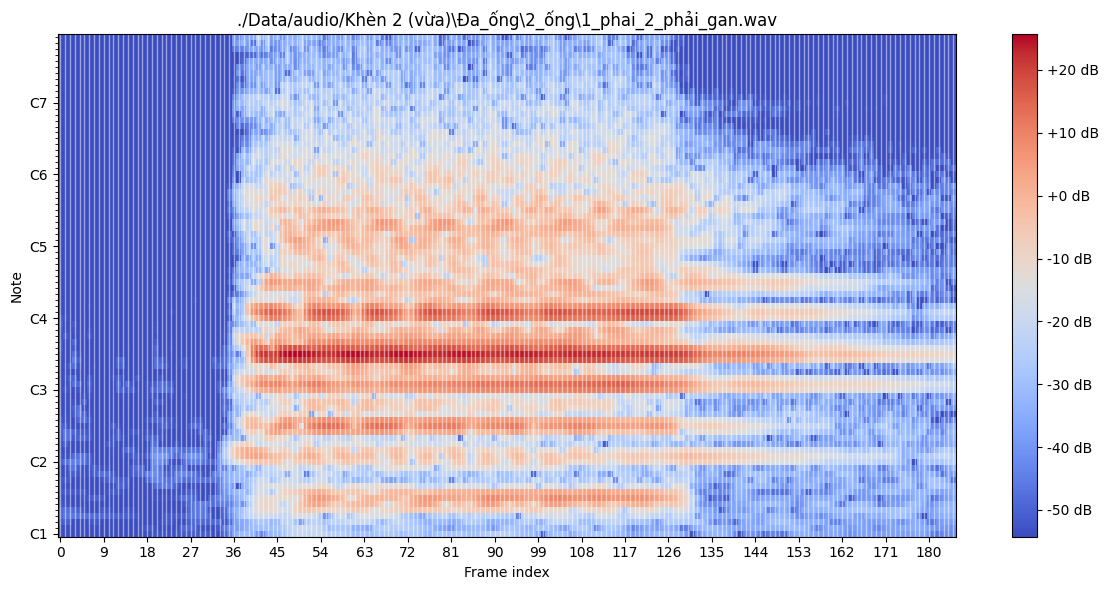

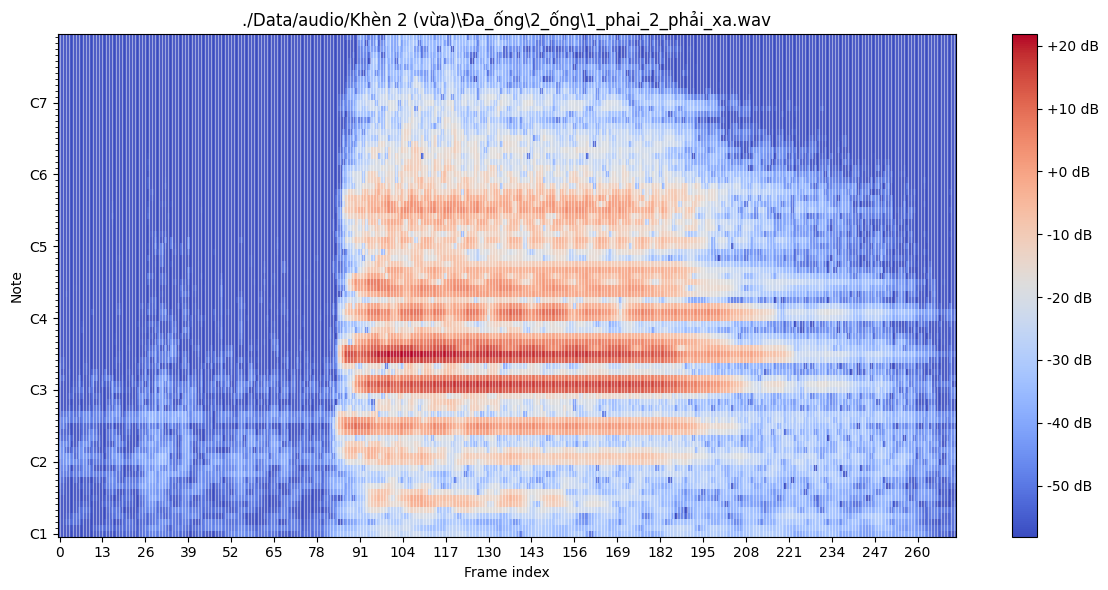

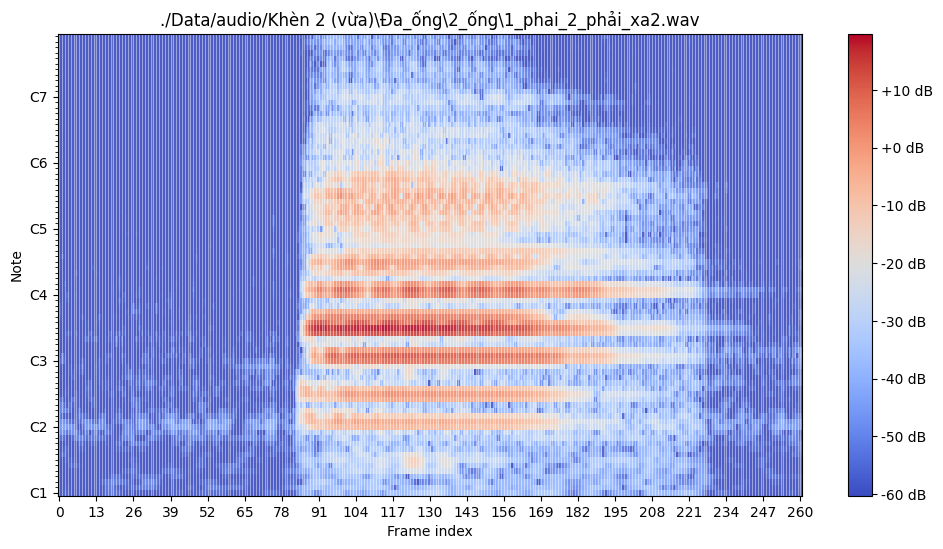

In [ ]:
# audios_paths = ["./Data/audio/Khèn 1", "./Data/audio/Khèn 2 (vừa)","./Data/audio/Khèn 3 (vừa)", "./Data/audio/Khèn 4 (to)", "./Data/audio/Khèn 5 (to)"]

# for audios_path in audios_paths:
#     analyzing_spectrograms_for_audios_in_folder(audios_path)

# audio_path = "./Data/audio/Khèn 1"
# save_path = "./Experiments/Data_Augmentation/Khèn 1"
# analyzing_spectrograms_after_au_from_a_qeej(audio_path, save_path, [1,2,3])
# audio_paths = ["./Data/audio/Khèn 2 (vừa)","./Data/audio/Khèn 3 (vừa)"]
# for audio_path in audio_paths:
#     analyzing_spectrograms_for_audios_in_folder(audio_path)

audio_path = "./Data/audio_extends/Khèn 6/Đơn_ống/1 phải hít vào_1.wav"
analyze_spectrogram_by_CQT_of_audio(audio_path, "", False)
    